## data loading

In [1]:
import sys
import os


sys.path.append('..')
os.chdir('..')

In [ ]:
# dataset
import os
import torch

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset


torch.set_printoptions(profile="full")

DATA_DIR = os.getenv('DATA_DIR')

config = Configuration.create('./configs/paraff-visionund-data.yaml', volatile=True)
data, = loadDataset(config, data_dir=DATA_DIR, splits='*0/1')

it = iter(data)
batch = next(it)
batch

/home/camus/work/deep-starry/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.


In [ ]:
batch['input_ids'].shape, batch['target_mask'].shape, batch['img_emb'].shape, batch['image_seq_mask'].shape

(torch.Size([2, 765]),
 torch.Size([2, 765]),
 torch.Size([2, 1, 576, 1024]),
 torch.Size([2, 765]))

In [ ]:
print(data.dataset.tokenizer.decode(batch['input_ids'][0]))

<｜begin▁of▁sentence｜>You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.

<|User|>: <begin_of_image><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><imag

---
## model

In [1]:
import sys
import os


sys.path.append('..')
os.chdir('..')

In [2]:
# dataset
import os
import torch

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel


torch.set_printoptions(profile="full")

DATA_DIR = os.getenv('DATA_DIR')

config = Configuration.create('./configs/paraff-visionund-test.yaml', volatile=True)
train, = loadDataset(config, data_dir=DATA_DIR, splits='*0/1', device='cuda')
model = loadModel(config['model'], postfix='Loss').cuda()

it = iter(train)

batch = next(it)
loss, metric = model(batch)

loss, metric

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.
2025-03-20 19:45:57.047390: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-20 19:45:57.047425: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-20 19:45:57

(tensor(12.1250, device='cuda:0', dtype=torch.bfloat16,
        grad_fn=<NllLossBackward0>),
 {'loss': 12.125, 'acc': 0.0})

In [3]:
emb = model.deducer.janus.get_input_embeddings()
emb

Embedding(102400, 4096)

In [4]:
model.deducer.janus.config.hidden_size

4096

In [5]:
from starry.utils.trainer import print_metric


print_metric(metric)

'loss: 12.1250, acc: 0.0000'

In [6]:
type(metric) == dict

True

In [7]:
list(map(lambda item: f'{item[0]}: {item[1]:.4f}',
			filter(lambda item: type(item[1]) in [int, float],
				metric.items())))

['loss: 12.1250', 'acc: 0.0000']

In [8]:
loss.backward()

In [9]:
model.eval()


with torch.no_grad():
	inspection = model.inspectRun(batch)

inspection['target_flat'].shape, inspection['pred_flat'].shape

(torch.Size([139]), torch.Size([139, 102400]))

In [10]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/Janus-Pro-7B")
tokenizer

LlamaTokenizerFast(name_or_path='deepseek-ai/Janus-Pro-7B', vocab_size=100000, model_max_length=16384, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<｜begin▁of▁sentence｜>', 'eos_token': '<｜end▁of▁sentence｜>', 'pad_token': '<｜▁pad▁｜>', 'additional_special_tokens': ['<image_placeholder>', '<patch_placeholder>', '<|ref|>', '<|/ref|>', '<|det|>', '<|/det|>', '<|grounding|>', '<|User|>', '<|Assistant|>']}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	100000: AddedToken("<｜begin▁of▁sentence｜>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	100001: AddedToken("<｜end▁of▁sentence｜>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	100002: AddedToken("ø", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
	100003: AddedToken("ö", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
	100004: AddedToken("ú", rstrip=Fa

In [11]:
tokenizer.decode(inspection['target_flat'])

'OM K4 TN2 TD2 S1 Cg Mu g As W2 D8 Bl Ecre EslurL e Osup W D8 c As W D8 Br Mu g As Osup W2 D8 Bl e W D8 c As Osup W D8 Br Md g As W2 D8 Bl e Osup W D8 c As W D8 Br Md g As Osup W2 D8 Bl e W D8 c As W D8 Br VB S2 Cf Mu g As Osub D2 Dot g As D8 Dot Bl g As D16 Br VB S2 Cf Mu c As Osub Osub D1 EOM<｜end▁of▁sentence｜>'

In [12]:
for k, v in inspection.items():
	inspection[k] = v.cpu()

inspection['target_flat'] = inspection['target_flat'].tolist()

In [13]:
inspection['pred_flat'].shape

torch.Size([139, 102400])

In [14]:
vocab = []

id_set = set(inspection['target_flat'])
id_list = list(id_set)

for id in id_list:
	vocab.append(tokenizer.decode(id))

# replace value of 'target_flat' with its index in id_list
inspection['target_flat'] = [id_list.index(i) for i in inspection['target_flat']]

# construct a matrix, to map id in inspection['target_flat'] to the index in vocab
mapping = torch.nn.functional.one_hot(torch.tensor(id_list), num_classes=inspection['pred_flat'].shape[-1]).transpose(0, 1).to(model.dtype)

inspection['pred_flat'] = inspection['pred_flat'] @ mapping

vocab

[' c',
 'sl',
 '1',
 '2',
 ' TN',
 '4',
 ' VB',
 '6',
 '8',
 ' D',
 '<｜end▁of▁sentence｜>',
 ' W',
 ' E',
 'L',
 ' e',
 ' g',
 'sub',
 ' S',
 ' As',
 'g',
 'ur',
 ' K',
 'cre',
 ' C',
 ' Dot',
 ' Mu',
 'OM',
 ' TD',
 'sup',
 ' Cf',
 ' Bl',
 ' Md',
 ' O',
 ' Br']

In [15]:
len(vocab)

34

In [16]:
inspection['pred_flat'].shape

torch.Size([139, 34])

In [17]:
from starry.paraff.viewer import ParaffViewer


viewer = ParaffViewer(dict(_vocab=''))
viewer.vocab = vocab
viewer

In [18]:
import matplotlib


matplotlib.use('module://matplotlib_inline.backend_inline')

In [19]:
%matplotlib inline

/home/camus/work/deep-starry/env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


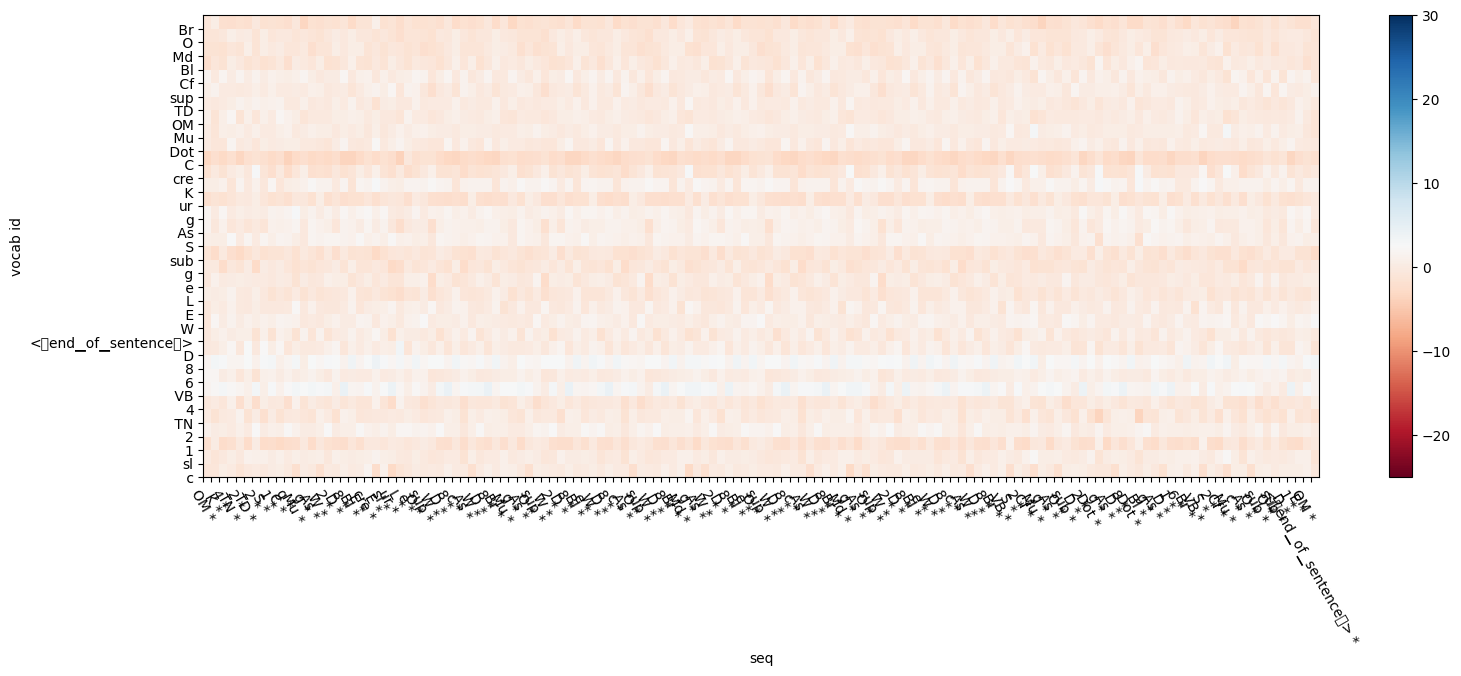

In [20]:
import matplotlib.pyplot as plt


plt.figure(figsize=(18, 6))

viewer.showBatch(None, inspection)

plt.show()

---

In [21]:
print('\n'.join(model.deducer.state_dict().keys()))

add_embedding
lm_head.weight
